[INFO] PROJECT_ROOT = C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis
[INFO] CSV exists: True -> C:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\ncr_ride_bookings_with_weather_filled_scaled_short.csv

===== TRAINING SUMMARY =====
Best model        : rf
Validation report : {'model': 'rf', 'accuracy': 0.9374893428366811, 'precision': 0.9126375290198849, 'recall': 0.9943909815782238, 'f1': 0.9517618884707494, 'roc_auc': 0.9684372369868492}
Saved model (.pkl): c:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised\best_cls_rf__target_completed_.pkl
Preds CSV         : c:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised\cls_best_rf_preds.csv
Split CSV         : c:\Users\yauli\OneDrive\桌面\MADS-MS2-Uber-Analysis\supervised\split_assignments_classification.csv

===== CLASSIFICATION REPORT (validation) =====
              precision    recall  f1-score   support

           0     0.9893    0.8446    0.9112     11138
           1     0.9126    0.9944    0.9518     18185

    ac

<Figure size 640x480 with 0 Axes>

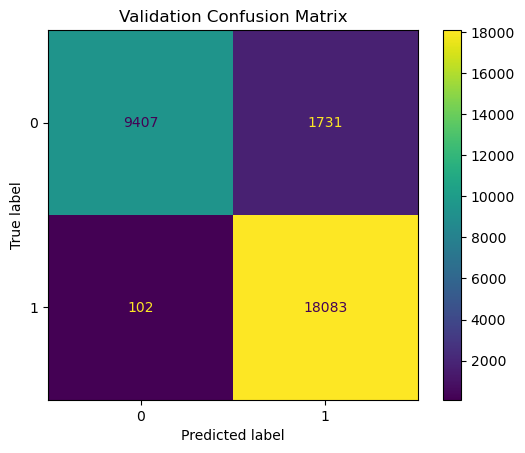


===== PREVIEW: validation predictions =====


,y_true,y_pred,proba
0,1,1,0.595
1,0,0,0.085
2,0,0,0.080
3,0,0,0.015
4,1,1,0.995


In [1]:
# === Supervised modeling

import os, sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Step 1: ensure we can import project_package from the project root ---
def add_project_root(marker_folder="project_package", max_up=6):
    cur = pathlib.Path(".").resolve()
    for _ in range(max_up + 1):
        if (cur / marker_folder).is_dir():
            if str(cur) not in sys.path:
                sys.path.insert(0, str(cur))
            return cur
        cur = cur.parent
    raise RuntimeError(f"Could not find '{marker_folder}' up to {max_up} levels above.")

PROJECT_ROOT = add_project_root()
print("[INFO] PROJECT_ROOT =", PROJECT_ROOT)

# --- Step 2: locate CSV (assumes at project root; change to datasets/... if you stored it there) ---
CSV_NAME = "ncr_ride_bookings_with_weather_filled_scaled_short.csv"
csv_path = PROJECT_ROOT / CSV_NAME
if not csv_path.exists():
    # fallback: try ./datasets
    alt = PROJECT_ROOT / "datasets" / pathlib.Path(CSV_NAME).name
    if alt.exists():
        csv_path = alt
print("[INFO] CSV exists:", csv_path.exists(), "->", csv_path)
if not csv_path.exists():
    raise FileNotFoundError(
        f"CSV not found at {csv_path}. If your file is in ./datasets/, set CSV_NAME = 'datasets/{CSV_NAME}'."
    )

# --- Step 3: import trainer and run classification ---
from project_package.modeling import train_classification_from_csv

res = train_classification_from_csv(
    csv_path=str(csv_path),
    target_col=None,                     # None => derive _target_completed_ from "Booking Status"
    id_cols=["Booking ID", "Customer ID"],
    artifacts_dir="supervised",          # will resolve to <project_root>/artifacts/supervised/ (with updated modeling.py)
    valid_ratio=0.20,
    random_state=42,
    tune_row_cap=40000,                  # speed-up tuning; final model refits on full train
)

print("\n===== TRAINING SUMMARY =====")
print("Best model        :", res.best_model_name)
print("Validation report :", res.report)
print("Saved model (.pkl):", res.model_path)
print("Preds CSV         :", res.preds_csv_path)
print("Split CSV         :", res.split_csv_path)

# --- Step 4: quick diagnostics on validation set ---
preds = pd.read_csv(res.preds_csv_path)
y_true = preds["y_true"].values
y_pred = preds["y_pred"].values

print("\n===== CLASSIFICATION REPORT (validation) =====")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

print("\n===== PREVIEW: validation predictions =====")
display(preds.head())
